This notebook reads, cleans, and explores the fatigue database from **Zhang, Z., & Xu, Z. (2023). Fatigue database of additively manufactured alloys. Scientific Data, 10, 249. https://doi.org/10.1038/s41597-023-02150-x.**

# Imports

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
from functools import reduce
import seaborn as sns
import re
import unicodedata

# Read Data File

In [122]:
file = "FatigueData-AM2022.xlsx"

# read all sheets
all_sheets = pd.read_excel(file, sheet_name=None, header=0)

print(all_sheets.keys())

dict_keys(['S-N', 'e-N', 'dadn', 'parameter'])


In [123]:
for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):

    print(f"\nDataset {i}")
    print("Sheet:", sheet_name)
    print(df.columns.tolist())


Dataset 1
Sheet: S-N
['dataset id', 'life\nN (cycle)', 'stress amplitude\nσa (MPa)', 'runout']

Dataset 2
Sheet: e-N
['dataset id', 'life\nN (cycle)', 'strain amplitude\nεa (mm/mm)', 'runout']

Dataset 3
Sheet: dadn
['dataset id', 'stress intensity factor range\nΔK (MPa*m^(1/2))', 'crack growth rate \nda/dn (m/cycle)']

Dataset 4
Sheet: parameter
['Unnamed: 0', 'metadata', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'fatigue', 'Unnamed: 10', 'materials', 'AM', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'processing', 'testing', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'static mechanical properties', 'Unnamed: 43', 'Un

In [124]:
for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):

    print("\n" + "="*60)
    print(f"Sheet {i}: {sheet_name}")
    print("="*60)

    print(df.describe())

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    # print("\nFirst rows:")
    # print(df.head())

    print("\nMissing values:")
    print(df.isnull().sum())


Sheet 1: S-N
         dataset id  life\nN (cycle)  stress amplitude\nσa (MPa)       runout
count  15146.000000     1.514600e+04                15146.000000  15146.00000
mean     792.986003     1.844821e+07                  285.818193      0.12221
std      457.581397     1.472127e+08                  189.421194      0.32754
min        1.000000     9.710731e+00                    5.760575      0.00000
25%      396.000000     6.502688e+04                  138.464799      0.00000
50%      780.000000     2.443496e+05                  249.958188      0.00000
75%     1187.000000     1.599869e+06                  375.990143      0.00000
max     1610.000000     8.496147e+09                 1591.682267      1.00000

Shape:
(15146, 4)

Columns:
['dataset id', 'life\nN (cycle)', 'stress amplitude\nσa (MPa)', 'runout']

Missing values:
dataset id                    0
life\nN (cycle)               0
stress amplitude\nσa (MPa)    0
runout                        0
dtype: int64

Sheet 2: e-N
        d

# Clean Column Names

## Remove Merged Headers
remove merged headers in row 1 of "parameters" and make row 2 the header row

In [125]:
# reread only the parameter sheet with row 2 as header
all_sheets["parameter"] = pd.read_excel(
    file,
    sheet_name="parameter",
    header=1
)

The "parameters" sheet includes many missing values. The others include none. 

## Merged Sheets
merge all the sheets where possible on dataset id

In [126]:
dfs = []

for sheet_name, sheet_df in all_sheets.items():
    sheet_df = sheet_df.copy()

    # standardize dataset id column before merge
    sheet_df.columns = [
        str(col).strip().lower().replace(" ", "_")
        for col in sheet_df.columns
    ]

    # make sure dataset_id is consistent
    sheet_df = sheet_df.rename(columns={
        "dataset_id": "dataset_id",
        "datasetid": "dataset_id",
        "dataset_id_": "dataset_id",
        "dataset": "dataset_id"
    })

    dfs.append(sheet_df)

merged_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="dataset_id",
        how="outer",
        suffixes=("", "_dup")
    ),
    dfs
)

print(merged_df.shape)
print(merged_df.columns.tolist())

(195047, 55)
['dataset_id', 'life\nn_(cycle)', 'stress_amplitude\nσa_(mpa)', 'runout', 'life\nn_(cycle)_dup', 'strain_amplitude\nεa_(mm/mm)', 'runout_dup', 'stress_intensity_factor_range\nδk_(mpa*m^(1/2))', 'crack_growth_rate_\nda/dn_(m/cycle)', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_\n(w)', 'scan_speed_\n(mm/s)', 'hatch_space_\n(μm)', 'layer_thickness_\n(μm)', 'preheat_temperature_\n(°c)', 'direciton_of_specimen_\n(°)', 'am_environment', 'scan_pattern', 'layer_scan_rotation_\n(°)', 'voltage_\n(v)', 'current_\n(a)', 'speed_function', 'powder_feed_rate_\n(g/s)', 'wire_feed_rate_\n(mm/s)', 'types_of_feedstock', 'size_of_feedstock_\n(μm)', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_\n(°c)', 'fatigue_environment', 'load_ratio', 'frequency_\n(hz)', 

## Clean Column Names
clean merged dataframe

In [127]:
def clean_column_name(col):
    col = str(col)

    symbol_map = {
        "σ": "sigma",
        "Δ": "delta",
        "µ": "micro",
        "√": "sqrt",
        "ε": "epsilon",
    }

    for symbol, replacement in symbol_map.items():
        col = col.replace(symbol, replacement)

    col = unicodedata.normalize("NFKD", col)
    col = col.encode("ascii", "ignore").decode()
    col = col.strip().lower()
    col = col.replace(" ", "_").replace("/", "_")
    col = re.sub(r"[^a-z0-9_]", "", col)
    col = re.sub(r"_+", "_", col)
    col = col.strip("_")
    col = col.replace("\n", "").replace("_x", "") 

    return col

clean_merged_df = merged_df.copy()
clean_merged_df.columns = [
    clean_column_name(col)
    for col in clean_merged_df.columns
]

# fix known typo
clean_merged_df = clean_merged_df.rename(columns={
    "direciton_of_specimen": "direction_of_specimen",
    "lifen_cycle": "lifecycle_n"
})

print(clean_merged_df.columns.tolist())

['dataset_id', 'lifecycle_n', 'stress_amplitudesigmaa_mpa', 'runout', 'lifen_cycle_dup', 'strain_amplitudeepsilona_mm_mm', 'runout_dup', 'stress_intensity_factor_rangek_mpam1_2', 'crack_growth_rate_da_dn_m_cycle', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direction_of_specimen', 'am_environment', 'scan_pattern', 'layer_scan_rotation', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_g_s', 'wire_feed_rate_mm_s', 'types_of_feedstock', 'size_of_feedstock_m', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimens_description', 'critical_crossse

## Remove Columns
remove irrelevant or duplicate columns

In [128]:
# find duplicate columns created during merge
dup_cols = [col for col in clean_merged_df.columns
            if "_dup" in col]

cols_to_drop = [
    "runout",
    "title",
    "authors",
    "source_of_the_publication",
    "year_of_publication",
    "institution",
    "country_and_region",
    "funding_agency",
    "doi",
    "am_environment",
    "rating_score",
    "runout_y",
    "lifen_cycle_y",
    "am_machine"
]

# combine lists
cols_to_drop.extend(dup_cols)

# drop columns
clean_merged_df = clean_merged_df.drop(
    columns=cols_to_drop,
    errors="ignore"
)

print(clean_merged_df.columns.to_list())

['dataset_id', 'lifecycle_n', 'stress_amplitudesigmaa_mpa', 'strain_amplitudeepsilona_mm_mm', 'stress_intensity_factor_rangek_mpam1_2', 'crack_growth_rate_da_dn_m_cycle', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direction_of_specimen', 'scan_pattern', 'layer_scan_rotation', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_g_s', 'wire_feed_rate_mm_s', 'types_of_feedstock', 'size_of_feedstock_m', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimens_description', 'critical_crosssection_size_of_specimensmm', 'stress_concentration_factor_of_specimens', 'youngs_modulus_gpa', 'yield_strength_mpa', 'ultimate_tensile_strength_mpa', 'elongation']


In [129]:
# create a dataframe, workflow_df, with only the necessary columns
irrel_cols = ['method_of_extraction',
              'voltage_v',
              'current_a',
              'speed_function',
              'powder_feed_rate_g_s',
              'wire_feed_rate_mm_s',
              'types_of_feedstock',
              'size_of_feedstock_m',
              'processing_sequence_and_parameters',
              'types_of_fatigue_tests',
              'fatigue_machine',
              'fatigue_standard'
]

workflow_df = clean_merged_df.copy()

# drop columns
workflow_df = workflow_df.drop(
    columns=irrel_cols,
    errors="ignore"
)

print(workflow_df.columns.to_list())

['dataset_id', 'lifecycle_n', 'stress_amplitudesigmaa_mpa', 'strain_amplitudeepsilona_mm_mm', 'stress_intensity_factor_rangek_mpam1_2', 'crack_growth_rate_da_dn_m_cycle', 'types_of_fatigue_data', 'name_of_the_material', 'types_of_am', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direction_of_specimen', 'scan_pattern', 'layer_scan_rotation', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'load_control', 'specimens_description', 'critical_crosssection_size_of_specimensmm', 'stress_concentration_factor_of_specimens', 'youngs_modulus_gpa', 'yield_strength_mpa', 'ultimate_tensile_strength_mpa', 'elongation']


## Standarize Column Names
standarize column names in workflow dataframe

In [130]:
# standardize selected columns in workflow_df

rename_map = {

    # target
    "lifecycle_n": "Nf",

    # loading
    "stress_amplitudesigmaa_mpa": "stress_amp",
    "strain_amplitudeepsilona_mm_mm": "strain_amp",
    "load_ratio": "r_ratio",
    "frequency_hz": "frequency_hz",
    "load_control": "load_control",

    # fracture mechanics
    "stress_intensity_factor_rangek_mpam1_2": "deltaK",
    "crack_growth_rate_da_dn_m_cycle": "dadN",

    # material
    "name_of_the_material": "material",
    "youngs_modulus_gpa": "E_gpa",
    "yield_strength_mpa": "yield_strength",
    "ultimate_tensile_strength_mpa": "uts",
    "elongation": "elongation",

    # additive manufacturing process
    "types_of_am": "am_process",
    "am_machine": "am_machine",
    "power_w": "power_w",
    "scan_speed_mm_s": "scan_speed",
    "hatch_space_m": "hatch_spacing",
    "layer_thickness_m": "layer_thickness",
    "preheat_temperature_c": "preheat_temp",

    # build/specimen
    "direction_of_specimen": "build_direction",
    "critical_crosssection_size_of_specimensmm": "spec_cross_area_mm",
    "stress_concentration_factor_of_specimens": "Kt",

    # environments
    "am_environment": "am_environment",
    "fatigue_environment": "fatigue_environment",
    "fatigue_temperature_c": "fatigue_temp",

    # scan strategy
    "scan_pattern": "scan_pattern",
    "layer_scan_rotation": "scan_rotation",

    # metadata
    "types_of_fatigue_data": "fatigue_data_type",
    "specimens_description": "specimen_description",
}

workflow_df = workflow_df.rename(columns=rename_map)

print(workflow_df.columns.tolist())

['dataset_id', 'Nf', 'stress_amp', 'strain_amp', 'deltaK', 'dadN', 'fatigue_data_type', 'material', 'am_process', 'power_w', 'scan_speed', 'hatch_spacing', 'layer_thickness', 'preheat_temp', 'build_direction', 'scan_pattern', 'scan_rotation', 'fatigue_temp', 'fatigue_environment', 'r_ratio', 'frequency_hz', 'load_control', 'specimen_description', 'spec_cross_area_mm', 'Kt', 'E_gpa', 'yield_strength', 'uts', 'elongation']


## Final Working Dataframe
final, merged dataframe with clean column names to deal with missing values

In [131]:
df = workflow_df.copy()

print(df.columns.tolist())
df.head()

['dataset_id', 'Nf', 'stress_amp', 'strain_amp', 'deltaK', 'dadN', 'fatigue_data_type', 'material', 'am_process', 'power_w', 'scan_speed', 'hatch_spacing', 'layer_thickness', 'preheat_temp', 'build_direction', 'scan_pattern', 'scan_rotation', 'fatigue_temp', 'fatigue_environment', 'r_ratio', 'frequency_hz', 'load_control', 'specimen_description', 'spec_cross_area_mm', 'Kt', 'E_gpa', 'yield_strength', 'uts', 'elongation']


,dataset_id,Nf,stress_amp,strain_amp,deltaK,dadN,fatigue_data_type,material,am_process,power_w,...,r_ratio,frequency_hz,load_control,specimen_description,spec_cross_area_mm,Kt,E_gpa,yield_strength,uts,elongation
0,1,20047.798627,233.965265,NaN,NaN,NaN,sn,316L,L-PBF,250,...,0.1,10,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
1,1,50630.187289,215.905854,NaN,NaN,NaN,sn,316L,L-PBF,250,...,0.1,10,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
2,1,94372.343349,197.999439,NaN,NaN,NaN,sn,316L,L-PBF,250,...,0.1,10,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
3,1,152595.813892,180.016661,NaN,NaN,NaN,sn,316L,L-PBF,250,...,0.1,10,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2
4,1,270549.972140,161.845026,NaN,NaN,NaN,sn,316L,L-PBF,250,...,0.1,10,force,circular cross-section; with drawing,3,1.0,NaN,490.0,656.0,48.2


# Clean Data

In [132]:
# quick overview
print(df.shape)
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False))

(195047, 29)
dataset_id                int64
Nf                      float64
stress_amp              float64
strain_amp              float64
deltaK                  float64
dadN                    float64
fatigue_data_type        object
material                 object
am_process               object
power_w                  object
scan_speed               object
hatch_spacing            object
layer_thickness          object
preheat_temp             object
build_direction          object
scan_pattern             object
scan_rotation           float64
fatigue_temp              int64
fatigue_environment      object
r_ratio                  object
frequency_hz             object
load_control             object
specimen_description     object
spec_cross_area_mm       object
Kt                      float64
E_gpa                   float64
yield_strength          float64
uts                     float64
elongation              float64
dtype: object
strain_amp              193207
stress_amp    

## Remove Empty & Duplicate Rows
remove fully empty rows and duplicate values

In [133]:
# remove fully empty rows
df = df.dropna(how="all")

# remove duplicate rows
df = df.drop_duplicates()

print(df.shape)

(193890, 29)


Shape reduced (195047, 31) to (193890, 31) so almost 2,000 rows were removed.

## Clean Text Columns

In [134]:
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    )

## Clean Numeric Columns

In [135]:
numeric_cols = [
    "Nf",
    "stress_amp",
    "strain_amp",
    "deltaK",
    "dadN",
    "power_w",
    "scan_speed",
    "hatch_spacing",
    "layer_thickness",
    "preheat_temp",
    "fatigue_temp",
    "r_ratio",
    "frequency_hz",
    "spec_cross_area_mm",
    "Kt",
    "E_gpa",
    "yield_strength",
    "uts",
    "elongation",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

### Replace Impossible Values
replace physically impossible values

In [136]:
positive_cols = [
    "Nf",
    "stress_amp",
    "deltaK",
    "dadN",
    "power_w",
    "scan_speed",
    "hatch_spacing",
    "layer_thickness",
    "frequency_hz",
    "Kt",
    "E_gpa",
    "yield_strength",
    "uts",
]

for col in positive_cols:
    if col in df.columns:
        df.loc[df[col] <= 0, col] = pd.NA

## Clean String Values
clean string values as the columns to make everything lowercase, remove Greek letters, etc.

In [137]:
# clean non-numeric cell values
def clean_text_value(x):
    if pd.isna(x):
        return pd.NA

    x = str(x)

    symbol_map = {
        "σ": "sigma",
        "Δ": "delta",
        "µ": "micro",
        "√": "sqrt",
        "ε": "epsilon",
    }

    for symbol, replacement in symbol_map.items():
        x = x.replace(symbol, replacement)

    x = unicodedata.normalize("NFKD", x)
    x = x.encode("ascii", "ignore").decode()

    x = x.strip().lower()
    x = x.replace("/", "_")
    x = re.sub(r"[^a-z0-9_]", "", x)
    x = re.sub(r"_+", "_", x)
    x = x.strip("_")

    if x in ["", "nan", "none", "na", "n_a"]:
        return pd.NA

    return x

text_cols = df.select_dtypes(include=["object", "string"]).columns

for col in text_cols:
    df[col] = df[col].apply(clean_text_value)

## Missing Values
missing values in relevant columns are handled

In [138]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

strain_amp              192175
spec_cross_area_mm      182828
stress_amp              178782
Nf                      178782
E_gpa                   156889
scan_pattern            155402
preheat_temp            151620
scan_rotation           133210
hatch_spacing            99961
elongation               88232
yield_strength           84419
uts                      82687
power_w                  74210
scan_speed               73199
layer_thickness          51838
frequency_hz             49236
dadN                     16823
deltaK                   16823
build_direction          14271
r_ratio                   7927
specimen_description      1161
dtype: int64


## AM Process
only interested in L-PBF processes

In [139]:
# keep only LPBF specimens
df_lpbf = df[df["am_process"].fillna("") == "lpbf"]

print(df_lpbf.shape)
df_lpbf.head()

(111009, 29)


,dataset_id,Nf,stress_amp,strain_amp,deltaK,dadN,fatigue_data_type,material,am_process,power_w,...,r_ratio,frequency_hz,load_control,specimen_description,spec_cross_area_mm,Kt,E_gpa,yield_strength,uts,elongation
0,1,20047.798627,233.965265,NaN,NaN,NaN,sn,316l,lpbf,250,...,0.1,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2
1,1,50630.187289,215.905854,NaN,NaN,NaN,sn,316l,lpbf,250,...,0.1,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2
2,1,94372.343349,197.999439,NaN,NaN,NaN,sn,316l,lpbf,250,...,0.1,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2
3,1,152595.813892,180.016661,NaN,NaN,NaN,sn,316l,lpbf,250,...,0.1,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2
4,1,270549.972140,161.845026,NaN,NaN,NaN,sn,316l,lpbf,250,...,0.1,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2


### Fatigue Life Data
drop rows without Nf

In [140]:
df_life = df.dropna(subset=["Nf", "stress_amp"])



### Crack Growth Data
drop rows without daDN

In [141]:
df_crack = df.dropna(subset=["deltaK", "dadN"])

print(df_crack.shape)
df_crack.head()

(177067, 29)


,dataset_id,Nf,stress_amp,strain_amp,deltaK,dadN,fatigue_data_type,material,am_process,power_w,...,r_ratio,frequency_hz,load_control,specimen_description,spec_cross_area_mm,Kt,E_gpa,yield_strength,uts,elongation
16986,1847,NaN,NaN,NaN,3.893058,5.309420e-10,dadn,ti6al4v,lpbf,<NA>,...,0.05,10.0,load,ctwithdrawing,<NA>,1.0,120.0,950.0,1144.0,NaN
16987,1847,NaN,NaN,NaN,12.649111,3.640871e-08,dadn,ti6al4v,lpbf,<NA>,...,0.05,10.0,load,ctwithdrawing,<NA>,1.0,120.0,950.0,1144.0,NaN
16988,1847,NaN,NaN,NaN,10.572607,1.529528e-08,dadn,ti6al4v,lpbf,<NA>,...,0.05,10.0,load,ctwithdrawing,<NA>,1.0,120.0,950.0,1144.0,NaN
16989,1847,NaN,NaN,NaN,20.579883,1.933091e-07,dadn,ti6al4v,lpbf,<NA>,...,0.05,10.0,load,ctwithdrawing,<NA>,1.0,120.0,950.0,1144.0,NaN
16990,1847,NaN,NaN,NaN,7.513516,7.478646e-09,dadn,ti6al4v,lpbf,<NA>,...,0.05,10.0,load,ctwithdrawing,<NA>,1.0,120.0,950.0,1144.0,NaN


### Final Clean Dataframe

In [142]:
# clean_df = df.copy()

# new clean df with only LPBF specimens
clean_df = df[df["am_process"] == "lpbf"].copy()

print(clean_df.shape)
print(clean_df.columns.tolist())
clean_df.head()

(111009, 29)
['dataset_id', 'Nf', 'stress_amp', 'strain_amp', 'deltaK', 'dadN', 'fatigue_data_type', 'material', 'am_process', 'power_w', 'scan_speed', 'hatch_spacing', 'layer_thickness', 'preheat_temp', 'build_direction', 'scan_pattern', 'scan_rotation', 'fatigue_temp', 'fatigue_environment', 'r_ratio', 'frequency_hz', 'load_control', 'specimen_description', 'spec_cross_area_mm', 'Kt', 'E_gpa', 'yield_strength', 'uts', 'elongation']


,dataset_id,Nf,stress_amp,strain_amp,deltaK,dadN,fatigue_data_type,material,am_process,power_w,...,r_ratio,frequency_hz,load_control,specimen_description,spec_cross_area_mm,Kt,E_gpa,yield_strength,uts,elongation
0,1,20047.798627,233.965265,NaN,NaN,NaN,sn,316l,lpbf,250,...,0.1,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2
1,1,50630.187289,215.905854,NaN,NaN,NaN,sn,316l,lpbf,250,...,0.1,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2
2,1,94372.343349,197.999439,NaN,NaN,NaN,sn,316l,lpbf,250,...,0.1,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2
3,1,152595.813892,180.016661,NaN,NaN,NaN,sn,316l,lpbf,250,...,0.1,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2
4,1,270549.972140,161.845026,NaN,NaN,NaN,sn,316l,lpbf,250,...,0.1,10.0,force,circularcrosssectionwithdrawing,3.0,1.0,NaN,490.0,656.0,48.2


# Exploratory Data Analysis

In [143]:
print(clean_df.describe())

          dataset_id            Nf    stress_amp   strain_amp        deltaK  \
count  111009.000000  1.206700e+04  12067.000000  1306.000000  97636.000000   
mean     1982.927546  2.113785e+07    281.364098     0.005454     15.867156   
std       477.658763  1.600735e+08    192.937341     0.004531     14.125554   
min         1.000000  9.710731e+00      5.760575     0.000653      1.043851   
25%      1950.000000  7.040079e+04    131.570246     0.002970      6.250941   
50%      2076.000000  2.598675e+05    245.118931     0.004017     11.574189   
75%      2199.000000  1.768072e+06    375.124084     0.006978     20.463774   
max      2460.000000  8.496147e+09   1291.298441     0.040115    108.338448   

               dadN     power_w  scan_speed  hatch_spacing  layer_thickness  \
count  9.763600e+04     80736.0     79129.0        76217.0         100522.0   
mean   5.304689e-07  310.863097  935.112373     139.793845        42.383319   
std    2.412679e-06  203.291166  456.925746     103

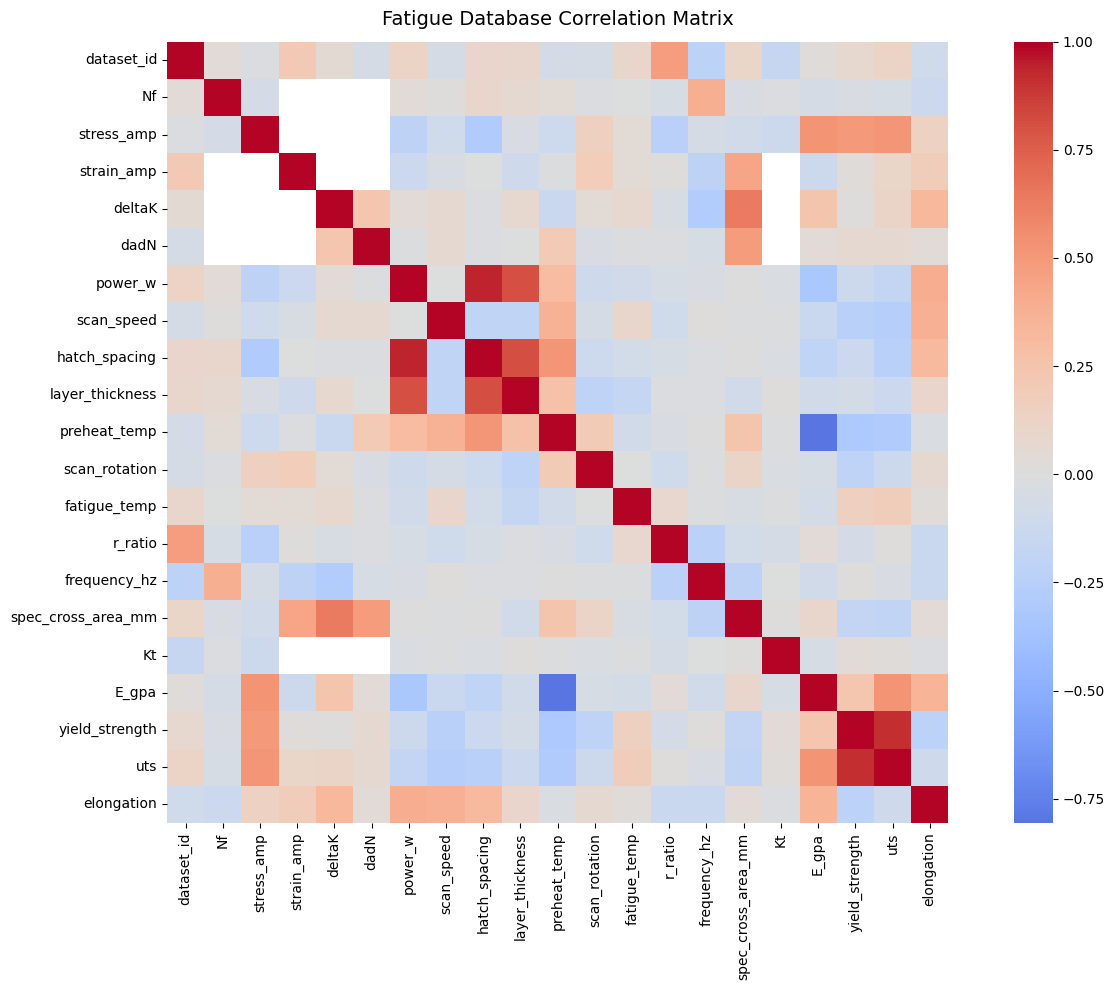

In [144]:
corr = clean_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            square=True,
            #annot=True,
            )
plt.title('Fatigue Database Correlation Matrix',
          fontdict={'fontsize':14}, pad=12)
plt.tight_layout()
plt.show()

Power, scan speed, hatch spacing, layer thickness, and temperature are all highly correlated. This is expected since they are all process parameters involved in the the VED and thus the number of defects.

Expectedly, the Young's modulus, yield strength, UTS, and elongation are all highly correlated.

# Sort by Material

In [145]:
materials = sorted(clean_df["material"].dropna().unique())

for m in materials:
    print(m)

155ph
174ph
18ni300
18ni30012083steel
18ni30012344steel
24crnimo
304l
316l
316lnitrogen
800h
a356alsi10mg
a356t6alsi10mg
a357
ad1
aif357
al474mg070sc032zr
al5024
alcu2mg15ni
alcusczr
almgsc
almgsczr
alnicu
alsi10mg
alsi10mg04
alsi12
alsi12mg
alsi7mg
alsi7mg06
alzn45mg1alsi12
astma131eh36steel
cl92phstainlesssteel
co28cr6mo
co29cr6mo
cocrfemnni
cocrmo
cocrmow
cocrw
crfeconi
cu72ni18si1cr
fe40mn20co20cr15si5
gh4169
h13steel
hastelloyx
in625
in718
in718316l
in738lc
ironbasedalloy
k536
maragingstainlesssteelcx
maragingsteel
maragingsteel300
maragingsteelms1
marm509
niti
questekal
scalmalloy
ss630
steelcopperfunctionallygradedmaterial
ti
ti10v2fe3al
ti13nb13zr
ti15zr4nb4ta
ti34nb13ta5zr02o
ti41nb
ti5al25sn
ti6al4v
ti6al4vnysz
ti6al7nb
we43
x3nicomoti1895steel


In [146]:
# define function to classify material type
def classify_material(material):

    if pd.isna(material):
        return "unknown"

    # 316L variants
    if ("316l" in material or
        "aisi 316l" in material or
        "ss316l" in material):
        return "316L"

    # Ti-6Al-4V variants
    elif ("ti-6al-4v" in material or
          "ti6al4v" in material or
          "ti 6al 4v" in material or
          "tc4" in material):
        return "Ti-6Al-4V"

    # everything else
    else:
        return "other"

clean_df["material_group"] = clean_df["material"].apply(classify_material)
print(clean_df["material_group"].value_counts())
clean_df.groupby("material_group").size()

material_group
other        70398
Ti-6Al-4V    32289
316L          8322
Name: count, dtype: int64


material_group
316L          8322
Ti-6Al-4V    32289
other        70398
dtype: int64

In [147]:
summary_by_group = clean_df.groupby("material_group").agg({
    "Nf": ["count", "mean", "median"],
    "stress_amp": ["mean", "min", "max"]
})

summary_by_group

Nf                               stress_amp             \
               count          mean         median        mean        min   
material_group                                                             
316L            1465  2.209332e+06  292054.666297  253.160914  64.175679   
Ti-6Al-4V       3723  2.934318e+07  207788.922999  310.194304   5.760575   
other           6879  2.072818e+07  282231.933652  271.767180   9.884348   

                             
                        max  
material_group               
316L            1080.632267  
Ti-6Al-4V       1093.410895  
other           1291.298441

## Create Dataframes by Material
create different dataframes by material to make exportation of the csv smoother and analysis easier

In [148]:
df_316L = clean_df[clean_df["material_group"] == "316L"]

df_ti64 = clean_df[clean_df["material_group"] == "Ti-6Al-4V"]

df_other = clean_df[clean_df["material_group"] == "Other"]

# Export Clean Dataframe

In [149]:
clean_df.to_csv("fatigue_database_clean.csv", index=False)

df_316L.to_csv("316l_fatiguedata_clean.csv", index=False)

df_ti64.to_csv("ti64_fatiguedata_clean.csv", index=False)

df_other.to_csv("other_fatiguedata_clean.csv", index=False)

In [150]:
clean_df.to_json("fatigue_database_clean.json",
                 orient="records",
                 indent=4)